# Buyer Segmentation using Clustering

## Objective
Identify different buyer types based on:
- Demographics
- Investment purpose
- Financing behavior
- Geographic patterns

Models Used:
- K-Means Clustering
- Hierarchical Clustering

Evaluation:
- Elbow Method
- Silhouette Score

##Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

import warnings
warnings.filterwarnings('ignore')

##Load Datasets

In [ ]:
clients = pd.read_csv("/content/clients.csv")

properties = pd.read_csv("/content/properties.csv")

print("Clients Shape:",clients.shape)
print("Properties Shape:",properties.shape)

Clients Shape: (2000, 12)
Properties Shape: (10000, 9)


##Merge Datasets

In [ ]:
df = pd.merge(
    clients,
    properties,
    left_on='client_id',
    right_on='client_ref',
    how='inner'
)

print(df.shape)

(7305, 21)


In [ ]:
df.head(10)

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,referral_channel,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,90343,9,10-01-2024,Apartment,40,1090.32,"$351,419.29",Sold,C0001
1,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,4051,4,12-01-2024,Apartment,51,1608.84,"$496,266.41",Sold,C0001
2,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,150099,15,05-01-2025,Apartment,15,522.71,"$175,599.90",Sold,C0001
3,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,30432,3,12-01-2025,Apartment,50,713.67,"$223,479.12",Sold,C0001
4,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,150044,15,01-01-2024,Apartment,6,938.57,"$299,245.20",Sold,C0002
5,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,1045,1,02-01-2024,Apartment,45,756.21,"$248,525.12",Sold,C0002
6,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,90285,9,12-01-2024,Apartment,36,1582.79,"$505,127.63",Sold,C0002
7,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,200450,20,05-01-2025,Apartment,51,1062.33,"$336,892.39",Sold,C0002
8,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,30377,3,12-01-2025,Apartment,46,1599.81,"$451,305.59",Sold,C0002
9,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,...,Agency,10104,1,07-01-2024,Apartment,13,719.47,"$216,874.97",Sold,C0003


##Missing Values and Handling

In [ ]:
df.isnull().sum()

,0
client_id,0
client_type,0
first_name,0
last_name,0
date_of_birth,0
gender,0
country,0
region,0
acquisition_purpose,0
satisfaction_score,0


In [ ]:
for col in df.columns:

    if df[col].dtype=="object":

        df[col].fillna(
            df[col].mode()[0],
            inplace=True
        )

    else:

        df[col].fillna(
            df[col].median(),
            inplace=True
        )

print("Missing values handled")

Missing values handled


##Remove Duplicate Entries

In [ ]:
df.drop_duplicates(inplace=True)

print(df.shape)

(7305, 21)


##Normalize Labels

In [ ]:
for col in df.select_dtypes(include='object').columns:

    df[col]=df[col].astype(str)

    df[col]=df[col].str.strip()

    df[col]=df[col].str.lower()

print("Labels normalized")

Labels normalized


##Create Age Feature

In [ ]:
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce', format='mixed', dayfirst=False)
df['Age'] = (
    pd.Timestamp.now().year
    - df['date_of_birth'].dt.year
)

# Fill NaN values in 'Age' column using its median
# This is crucial as KMeans cannot handle NaNs
if df['Age'].isnull().any():
    df['Age'] = df['Age'].fillna(df['Age'].median())

print("Missing values in Age after calculation and filling:", df['Age'].isnull().sum())
df[['Age']].head(10)

Missing values in Age after calculation and filling: 0


,Age
0,58
1,58
2,58
3,58
4,64
5,64
6,64
7,64
8,64
9,67


##Label Encoding

In [ ]:
le=LabelEncoder()

binary_cols=[
    'gender',
    'loan_applied'
]

for col in binary_cols:

    df[col]=le.fit_transform(
        df[col]
    )

##One Hot Encoding

In [ ]:
categorical_cols=[

'client_type',
'country',
'region',
'acquisition_purpose',
'referral_channel',
'unit_category',
'listing_status'

]

df=pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

df.head()

,client_id,first_name,last_name,date_of_birth,gender,satisfaction_score,loan_applied,listing_id,tower_number,transaction_date,...,region_wales,region_wallonia,region_washington,region_western australia,region_wyoming,region_zealand,acquisition_purpose_investment,referral_channel_client,referral_channel_website,unit_category_office
0,c0001,kareem,liu,1968-05-11,0,4,1,90343,9,10-01-2024,...,False,False,False,False,False,False,False,False,True,False
1,c0001,kareem,liu,1968-05-11,0,4,1,4051,4,12-01-2024,...,False,False,False,False,False,False,False,False,True,False
2,c0001,kareem,liu,1968-05-11,0,4,1,150099,15,05-01-2025,...,False,False,False,False,False,False,False,False,True,False
3,c0001,kareem,liu,1968-05-11,0,4,1,30432,3,12-01-2025,...,False,False,False,False,False,False,False,False,True,False
4,c0002,trystan,oconnor,1962-11-26,1,1,0,150044,15,01-01-2024,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# Clean 'sale_price' column in the main DataFrame df
# This is necessary for numerical operations on df['sale_price'] later (e.g., in cluster_analysis)
df['sale_price'] = df['sale_price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
print("df['sale_price'] converted to float.")

df['sale_price'] converted to float.


##Feature Selection

In [ ]:
features=[

'Age',
'satisfaction_score',
'loan_applied',
'floor_area_sqft',
'sale_price'

]

X=df[features]

##Scaling

In [ ]:
scaler=StandardScaler()

# Clean 'sale_price' column by removing '$' and ',' and converting to float
X['sale_price'] = X['sale_price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

X_scaled=scaler.fit_transform(X)

##Elbow Method

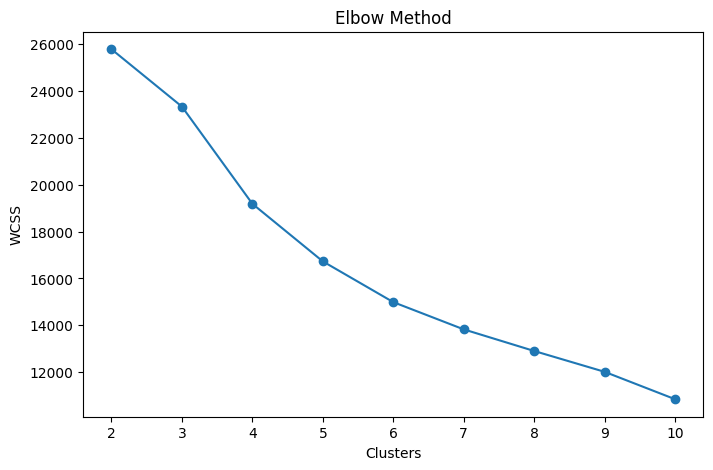

In [ ]:
wcss=[]

for i in range(2,11):

    kmeans=KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(
        kmeans.inertia_
    )


plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title(
    "Elbow Method"
)

plt.show()

##Silhouette Score

In [ ]:
for i in range(2,11):

    kmeans=KMeans(
        n_clusters=i,
        random_state=42
    )

    labels=kmeans.fit_predict(
        X_scaled
    )

    score=silhouette_score(
        X_scaled,
        labels
    )

    print(
        "Clusters:",
        i,
        "Score:",
        round(score,3)
    )

Clusters: 2 Score: 0.265
Clusters: 3 Score: 0.208
Clusters: 4 Score: 0.226
Clusters: 5 Score: 0.252
Clusters: 6 Score: 0.236
Clusters: 7 Score: 0.23
Clusters: 8 Score: 0.245
Clusters: 9 Score: 0.242
Clusters: 10 Score: 0.25


##Final KMeans Model

In [ ]:
kmeans=KMeans(
    n_clusters=4,
    random_state=42
)

df['Cluster']=kmeans.fit_predict(
    X_scaled
)

##Hierarchical Clustering

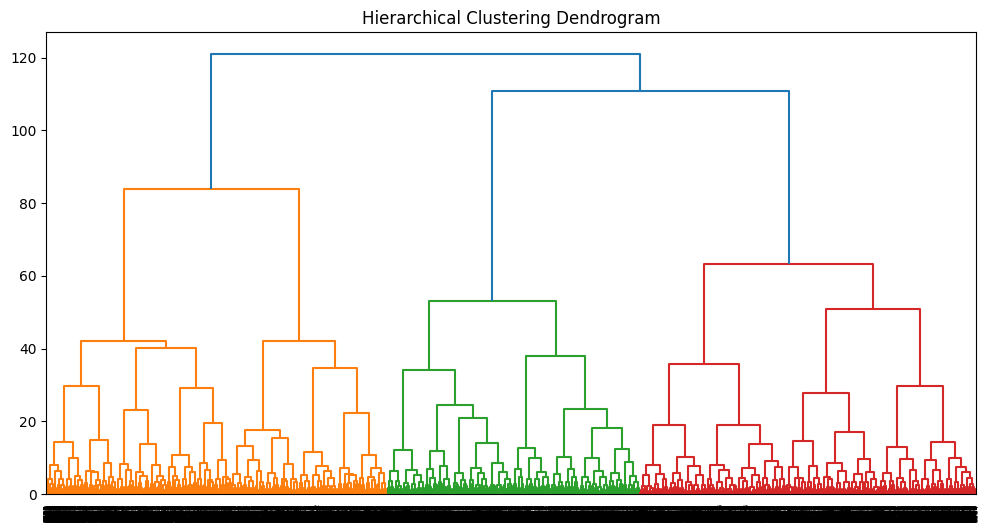

In [ ]:
linked=linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(
    linked
)

plt.title(
"Hierarchical Clustering Dendrogram"
)

plt.show()

##Cluster Analysis

In [ ]:
cluster_analysis=df.groupby(
'Cluster'
)[

['Age',
'satisfaction_score',
'sale_price']

].mean()

cluster_analysis

,Age,satisfaction_score,sale_price
Cluster,,,
0,56.271439,3.038979,450044.222799
1,52.920910,1.710184,245896.671176
2,59.537358,4.236517,236022.936571
3,56.637889,3.101135,471046.350602


##Geographic Distribution

In [ ]:
pd.crosstab(
    df['Cluster'],
    clients['region']
)

region,Alberta,Arizona,Baja California,Bavaria,Berlin,British Columbia,Brittany,Brussels,California,Capital Region,...,Texas,Utah,Victoria,Virginia,Wales,Wallonia,Washington,Western Australia,Wyoming,Zealand
Cluster,,,,,,,,,,,,,,,,,,,,,
0,5,21,1,3,3,1,1,4,121,2,...,12,20,1,12,3,5,10,0,0,1
1,4,26,2,5,3,5,6,5,129,0,...,16,17,3,17,6,7,20,1,0,0
2,5,26,3,1,3,5,8,2,225,2,...,18,29,4,16,5,1,26,2,0,1
3,13,35,1,3,2,9,1,1,158,1,...,10,21,5,20,3,2,17,3,1,0


##Loan Behavior

In [ ]:
pd.crosstab(
df['Cluster'],
df['loan_applied']
)

loan_applied,0,1
Cluster,,
0,0,1411
1,1289,557
2,1305,716
3,2027,0


##Cluster Visualization

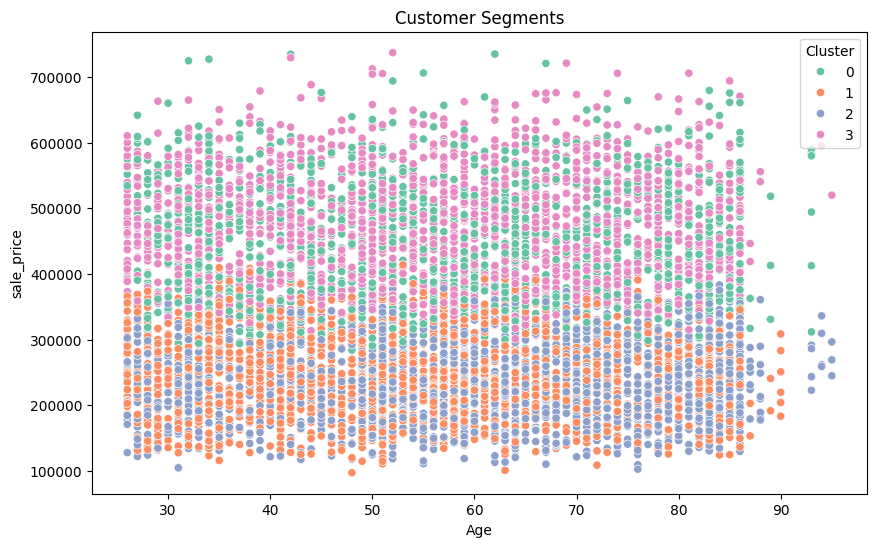

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(

x=df['Age'],
y=df['sale_price'],
hue=df['Cluster'],
palette='Set2'
)

plt.title(
"Customer Segments"
)

plt.show()

In [ ]:
segments=pd.DataFrame({

"Cluster":[
"C1",
"C2",
"C3",
"C4"
],

"Buyer Type":[
"Global Investors",
"First-Time Buyers",
"Corporate Buyers",
"Luxury Investors"
],

"Characteristics":[

"High income, investment purchases",

"Younger, loan dependent",

"Companies purchasing multiple units",

"High satisfaction, large investments"
]

})

segments

,Cluster,Buyer Type,Characteristics
0,C1,Global Investors,"High income, investment purchases"
1,C2,First-Time Buyers,"Younger, loan dependent"
2,C3,Corporate Buyers,Companies purchasing multiple units
3,C4,Luxury Investors,"High satisfaction, large investments"


## Key Findings

1. Buyer groups exhibit distinct demographic and financial patterns.

2. Younger buyers tend to rely more on loans.

3. High-value investors generally show stronger satisfaction scores.

4. Geographic regions influence purchasing behavior.

5. Corporate buyers display larger investment volume.

6. Clustering enables more targeted marketing strategies.

## Recommendations

- Build personalized property recommendations.
- Create financing offers for loan-dependent buyers.
- Develop premium campaigns for luxury investors.
- Improve investor targeting by region.

In [ ]:
import pickle

model_objects = {

    "model":kmeans,
    "scaler":scaler,
    "features":features

}

with open("model.pkl","wb") as f:

    pickle.dump(
        model_objects,
        f
    )

print("model.pkl saved successfully")

model.pkl saved successfully


In [ ]:
df["Cluster"]=clusters

######################################################
# SIDEBAR
######################################################

st.sidebar.title(
"Navigation"
)

page=st.sidebar.radio(

"Select Module",

[
"Buyer Segmentation Overview",
"Investor Behavior Dashboard",
"Geographic Buyer Analysis",
"Segment Insights Panel"
]

)

######################################################
# MODULE 1
######################################################

if page=="Buyer Segmentation Overview":

    st.header(
    "Cluster Distribution"
    )

    cluster_count=(
    df['Cluster']
    .value_counts()
    )

    fig=px.pie(

    values=cluster_count.values,
    names=cluster_count.index,

    title="Cluster Distribution"

    )

    st.plotly_chart(
    fig,
    use_container_width=True
    )

######################################################
# MODULE 2
######################################################

elif page=="Investor Behavior Dashboard":

    st.header(
    "Investment Patterns"
    )

    fig=px.scatter(

    df,

    x='sale_price',

    y='satisfaction_score',

    color='Cluster',

    size='floor_area_sqft',

    hover_data=['Age']

    )

    st.plotly_chart(
    fig,
    use_container_width=True
    )

######################################################
# MODULE 3
######################################################

elif page=="Geographic Buyer Analysis":

    st.header(
    "Regional Buyer Distribution"
    )

    region_cluster=pd.crosstab(

    df['region'],
    df['Cluster']

    )

    fig=px.bar(

    region_cluster,

    barmode='group'

    )

    st.plotly_chart(
    fig,
    use_container_width=True
    )

######################################################
# MODULE 4
######################################################

else:

    st.header(
    "Cluster Statistics"
    )

    summary=(

    df.groupby(
    "Cluster"
    )

    [

    ['Age',
    'sale_price',
    'satisfaction_score']

    ]

    .mean()

    )

    st.dataframe(
    summary
    )

NameError: name 'clusters' is not defined

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

st.set_page_config(
    page_title="Buyer Segmentation Dashboard",
    layout="wide"
)

st.title(
"🏠 Buyer Segmentation Dashboard"
)

######################################################
# Load Data
######################################################

clients=pd.read_csv(
"clients.csv"
)

properties=pd.read_csv(
"properties.csv"
)

df=pd.merge(

clients,
properties,

left_on='client_id',
right_on='client_ref'

)

######################################################
# Load Model
######################################################

with open(
"model.pkl",
"rb"
) as file:

    model_data=pickle.load(
    file
)

model=model_data["model"]

scaler=model_data["scaler"]

features=model_data["features"]

######################################################
# Basic Cleaning (Replicate notebook preprocessing)
######################################################

# Handling missing values (object columns with mode, numeric with median)
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# Remove duplicate entries
df.drop_duplicates(inplace=True)

# Normalize labels (strip and lowercase object columns)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Robustly convert 'date_of_birth' to datetime, handling mixed formats
df['date_of_birth']=pd.to_datetime(
df['date_of_birth'], errors='coerce', format='mixed', dayfirst=False
)

df['Age']=(
pd.Timestamp.now().year
-
df['date_of_birth'].dt.year
)

# Fill NaN values in 'Age' column using its median (for unparseable dates)
if df['Age'].isnull().any():
    df['Age'] = df['Age'].fillna(df['Age'].median())

# Label Encoding for binary columns
le = LabelEncoder()
binary_cols=[
    'gender',
    'loan_applied'
]

for col in binary_cols:
    df[col]=le.fit_transform(df[col])

# One-Hot Encoding for other categorical columns
categorical_cols=[
'client_type',
'country',
'region',
'acquisition_purpose',
'referral_channel',
'unit_category',
'listing_status'
]

df=pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

# Clean 'sale_price' column by removing '$' and ',' and converting to float
df['sale_price'] = df['sale_price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

X=df[features]

scaled_data=scaler.transform(
X
)

clusters=model.predict(
scaled_data
)

df["Cluster"]=clusters

######################################################
# SIDEBAR
######################################################

st.sidebar.title(
"Navigation"
)

page=st.sidebar.radio(

"Select Module",

[
"Buyer Segmentation Overview",
"Investor Behavior Dashboard",
"Geographic Buyer Analysis",
"Segment Insights Panel"
]

)

######################################################
# MODULE 1
######################################################

if page=="Buyer Segmentation Overview":

    st.header(
    "Cluster Distribution"
    )

    cluster_count=(
    df['Cluster']
    .value_counts()
    )

    fig=px.pie(

    values=cluster_count.values,
    names=cluster_count.index,

    title="Cluster Distribution"

    )

    st.plotly_chart(
    fig,
    use_container_width=True
    )

######################################################
# MODULE 2
######################################################

elif page=="Investor Behavior Dashboard":

    st.header(
    "Investment Patterns"
    )

    fig=px.scatter(

    df,

    x='sale_price',

    y='satisfaction_score',

    color='Cluster',

    size='floor_area_sqft',

    hover_data=['Age']

    )

    st.plotly_chart(
    fig,
    use_container_width=True
    )

######################################################
# MODULE 3
######################################################

elif page=="Geographic Buyer Analysis":

    st.header(
    "Regional Buyer Distribution"
    )

    region_cluster=pd.crosstab(

    df['region'],
    df['Cluster']

    )

    fig=px.bar(

    region_cluster,

    barmode='group'

    )

    st.plotly_chart(
    fig,
    use_container_width=True
    )

######################################################
# MODULE 4
######################################################

else:

    st.header(
    "Cluster Statistics"
    )

    summary=(=

    df.groupby(
    "Cluster"
    )

    [

    ['Age',
    'sale_price',
    'satisfaction_score']

    ]

    .mean()

    )

    st.dataframe(
    summary
    )

Writing app.py


Now that the `app.py` file has been created, run the following cell to launch your Streamlit dashboard. It will provide a public URL that you can click to access the dashboard in your browser.

In [2]:
!pip install -q streamlit --ignore-installed

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.1 MB/s eta 0:00:00
ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [1]:
!python -m streamlit run app.py >/dev/null &
!npm install -g localtunnel
!lt --port 8501

/usr/bin/python3: No module named streamlit
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 3s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇your url is: https://silly-views-repair.loca.lt
^C


In [ ]:
!ls

app.py	     cloudflared  model.pkl	  sample_data
clients.csv  logs.txt	  properties.csv


In [ ]:
!streamlit run app.py >/content/logs.txt &

/bin/bash: line 1: streamlit: command not found


In [ ]:
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared
!./cloudflared tunnel --url http://localhost:8501

2026-05-19T12:57:09Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-19T12:57:09Z INF Requesting new quick Tunnel on trycloudflare.com...
^C
